# 세그먼트 분류 ML이 정말 필요한가

추천을 만들기 전에 **고객을 몇 개 그룹(세그먼트)으로 나누는 머신러닝 모델**을 하나
끼워 넣을지 말지를 정하려고 한다. 흔한 설계라 일단 넣고 보기 쉬운데, 그 전에 물어야
할 게 있다.

> 그 모델이 없으면 못 하는 일이 실제로 있는가?

## 세그먼트 방식이란

흔히 쓰는 설계 그대로다. 두 단계뿐이다.

```
1. KMeans로 고객 4만 명을 K개 덩어리로 나눈다
2. 새 사용자가 오면 → 어느 덩어리에 속하는지 보고 → 그 덩어리 사람들이 쓰는 요금제를 추천
```

같은 세그먼트에 묶인 사람에게는 **항상 같은 답**이 나간다. 이게 이 방식의 전부이자
한계다.

## 이 노트북이 비교하는 것

| | 군집을 만들 때 쓰는 입력 |
|---|---|
| **필수만** | 예산, 데이터 사용량 — 폼에서 반드시 받는 2개 |
| **전체** | 위 2개 + 통화·문자·나이·OTT 등 폼이 받는 값 전부 |
| **필터 + 랭킹** | (대조군) 군집 없이 조건으로 거르고 점수로 정렬 |

입력을 다 받아 군집을 만들면 추천이 나아지는지, 아니면 필수 2개로도 같은지를 본다.

데이터는 `data/synthetic/customers_mvno.csv`(알뜰폰 합성 고객 4만 명).
없으면 먼저 `python src/make_synthetic_mvno.py`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd() / "src"))

from make_synthetic_mvno import OUT_PATH
from profile_input import DATA_BANDS, InputError, band_for, build_query
from recommend import TOP_N, broken_rules, load_plans, recommend

plans = load_plans()
plans = plans[plans["carrier_type"].eq("MVNO")].reset_index(drop=True)
customers = pd.read_csv(OUT_PATH, encoding="utf-8-sig")
# `plan_id`는 문자열인데, 알뜰폰 전용 파일은 요금제 코드가 전부 숫자라 CSV에서
# int64로 읽힌다. 맞춰 두지 않으면 뒤에서 isin()이 한 건도 안 맞아 세그먼트
# 추천이 조용히 0건이 된다.
customers["source_plan_id"] = customers["source_plan_id"].astype(str)

print(f"알뜰폰 요금제 {len(plans):,}개 · 합성 고객 {len(customers):,}명 · 추천 개수 {TOP_N}")

알뜰폰 요금제 2,236개 · 합성 고객 40,000명 · 추천 개수 5


## 1. 무엇으로 잘했다/못했다를 잴 것인가

추천에는 정답이 없다. "이 사람에게는 이 요금제가 정답"이라고 적힌 데이터가 세상에
없기 때문이다. 그래서 **정확도를 잴 수 없다.**

대신 잴 수 있는 게 있다. **사용자가 말한 조건을 지켰는가.**

3만원이라고 한 사람에게 5만원짜리를 내밀면 그건 취향 문제가 아니라 그냥 틀린 거다.
`recommend.broken_rules()`가 이 검사를 한다 — 추천 결과와 원래 요청을 받아서
어긴 조건의 이름을 돌려준다.

```python
broken_rules(추천결과, 요청)  ->  ['예산', '데이터']   # 어긴 게 없으면 []
```

검사하는 조건: 예산 · 데이터(무제한 포함) · 통화무제한 · 문자무제한 · 통화분수 ·
문자건수 · 알뜰폰 · 가입불가 · 나이.

> **알뜰폰 데이터라 죽어 있는 축이 둘 있다.** 전원이 알뜰폰 사용자라 `mvno_ok`가
> 항상 True고 `current_carrier`가 항상 "알뜰폰"이다. 그래서 '알뜰폰'·'가입불가'
> 위반은 구조적으로 0이 나온다. 이 두 축은 결론에서 빼고 읽어야 한다.

## 2. 합성 고객 한 명 → 폼 입력

고객 한 줄을 `build_query()` 인자로 바꾼다. **폼이 거부하는 값이 나오면 그대로 터진다** — 조용히 고쳐 넣지 않는다.

In [2]:
def persona_to_query(row: pd.Series) -> dict:
    """합성 고객 한 명을 폼 입력으로."""
    band = "무제한" if row["data_unlimited_need"] else band_for(row["data_gb_month"])
    want = row["ott_want"]
    return build_query(
        budget=int(row["budget_krw"]),
        data_band=band,
        voice_unlimited=bool(row["voice_unlimited_need"]),
        sms_unlimited=bool(row["sms_unlimited_need"]),
        voice_minutes=None if pd.isna(row["voice_minutes_need"]) else row["voice_minutes_need"],
        sms_count=None if pd.isna(row["sms_count_need"]) else row["sms_count_need"],
        mvno_ok=bool(row["mvno_ok"]),
        current_carrier=row["current_carrier"],
        age=int(row["age"]),
        ott_want=(want,) if isinstance(want, str) and want else (),
        ott_required=bool(row["ott_required"]),
        current_fee=int(row["current_fee_krw"]),
    )


who = customers.iloc[7]
print(who[["age", "data_gb_month", "voice_minutes_need", "budget_krw", "fee_group"]].to_string())
print("\n->", persona_to_query(who))

age                      43
data_gb_month          88.0
voice_minutes_need      NaN
budget_krw            15800
fee_group                 고

-> {'budget': 15800, 'data_gb': 100.0, 'data_unlimited': False, 'voice_unlimited': True, 'sms_unlimited': True, 'voice_minutes': None, 'sms_count': None, 'mvno_ok': True, 'current_carrier': None, 'age': 43, 'ott_want': (), 'ott_required': False, 'current_fee': 15800}


## 3. 훈련용과 시험용 나누기

세그먼트는 **훈련용 고객으로만** 만들고, 점수는 **시험용 고객**에서 잰다.
같은 사람으로 군집을 만들고 그 사람으로 시험 보면 당연히 잘 맞는다.

> **미리 밝혀 둘 기울기.** 시험용도 훈련용과 같은 합성 분포에서 나왔다. 즉 이 시험은
> 세그먼트 방식에 **유리하게 기울어 있다** — 자기가 배운 분포 안에서 시험을 보는
> 셈이다. 그런데도 지면 결론이 더 단단해진다.

In [3]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(customers, test_size=0.3, random_state=20260812)
print(f"훈련용 {len(train):,}명 · 시험용 {len(test):,}명")

훈련용 28,000명 · 시험용 12,000명


## 4. KMeans에 넣을 축 만들기

KMeans는 **거리**로 덩어리를 만든다. 두 사람이 얼마나 가까운지를 재서 가까운 것끼리
묶는다. 그래서 축을 숫자로 바꿔야 하고, 두 가지를 조심해야 한다.

**하나. 단위가 다르면 큰 숫자가 다 이긴다.**
예산은 900~24,000, 나이는 20~69다. 그냥 넣으면 나이 40살 차이(=40)보다 예산 100원
차이(=100)가 더 크게 잡힌다. 그래서 `StandardScaler`로 모든 축을 `(값 − 평균) ÷ 표준편차`로
바꾼다. 이러면 모든 축이 "평균에서 몇 배쯤 떨어졌나"라는 같은 잣대가 된다.

**둘. 값이 하나뿐이거나 겹치는 축은 빼야 한다.**
- `현재통신사`, `알뜰폰허용` — 알뜰폰 데이터라 전원 같은 값. 거리에 아무 기여도 못 한다
- `현재요금` — `예산`과 100% 같은 값. 넣으면 요금 축에 가중치가 두 배로 실린다

**셋. 무제한을 숫자로 바꾼다.**
통화·문자가 무제한이면 분수가 없다(`NaN`). 거리 계산에 넣으려면 숫자여야 해서
`9999`를 넣는다.

In [4]:
BAND_ORDER = {name: i for i, name in enumerate(DATA_BANDS)}
# ponytail: 센티넬 하나로 때운다. 무제한을 별도 차원으로 두는 게 정석이지만,
# 군집이 무제한/유제한부터 가르는 건 이 값으로도 똑같이 된다.
UNLIMITED_COUNT = 9999.0


def make_axes(df: pd.DataFrame) -> pd.DataFrame:
    """합성 고객을 KMeans가 쓸 숫자 축으로.

    폼이 실제로 받는 것만 넣는다 - 합성 데이터에는 정확한 GB가 있지만 실제
    사용자는 구간으로만 답하므로, band_for()로 구간(0~4)으로 되돌린 뒤 쓴다.
    """
    band = np.where(
        df["data_unlimited_need"],
        BAND_ORDER["무제한"],
        [BAND_ORDER[band_for(g)] if pd.notna(g) else BAND_ORDER["무제한"]
         for g in df["data_gb_month"]],
    )
    return pd.DataFrame({
        "예산": df["budget_krw"].to_numpy(),
        "데이터구간": band,
        "통화분수": df["voice_minutes_need"].fillna(UNLIMITED_COUNT).to_numpy(),
        "문자건수": df["sms_count_need"].fillna(UNLIMITED_COUNT).to_numpy(),
        "나이": df["age"].to_numpy(),
        "OTT희망": df["ott_want"].notna().astype(int).to_numpy(),
        "OTT필수": df["ott_required"].astype(int).to_numpy(),
    }, index=df.index)


REQUIRED_AXES = ["예산", "데이터구간"]
ALL_AXES = list(make_axes(customers.head(1)).columns)

print("필수 축:", REQUIRED_AXES)
print("전체 축:", ALL_AXES)
display(make_axes(train).describe().round(1).T)

필수 축: ['예산', '데이터구간']
전체 축: ['예산', '데이터구간', '통화분수', '문자건수', '나이', 'OTT희망', 'OTT필수']


,count,mean,std,min,25%,50%,75%,max
예산,28000.0,9666.2,9338.8,0.0,1900.0,8400.0,14000.0,57200.0
데이터구간,28000.0,1.6,1.1,0.0,1.0,1.0,3.0,4.0
통화분수,28000.0,7129.1,4454.3,0.0,310.0,9999.0,9999.0,9999.0
문자건수,28000.0,6984.3,4544.0,0.0,251.0,9999.0,9999.0,9999.0
나이,28000.0,47.9,12.1,20.0,38.0,48.0,57.0,69.0
OTT희망,28000.0,0.1,0.3,0.0,0.0,0.0,0.0,1.0
OTT필수,28000.0,0.0,0.2,0.0,0.0,0.0,0.0,1.0


## 5. K는 몇 개로 할까

`K = 6`으로 갈 텐데, 왜 6인지 근거를 먼저 보자. 두 가지를 본다.

- **관성(inertia)**: 각 점이 자기 중심에서 얼마나 떨어져 있나의 합. 낮을수록 촘촘하다.
  K를 키우면 무조건 낮아지므로, **꺾이는 지점**(엘보우)을 본다
- **실루엣(silhouette)**: 내 덩어리 안이 다른 덩어리보다 얼마나 더 가까운가.
  −1~1이고 높을수록 잘 갈렸다

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED = 20260812
probe = make_axes(train.sample(3_000, random_state=SEED))

rows = []
for k in range(2, 11):
    pipe = make_pipeline(StandardScaler(), KMeans(k, random_state=SEED, n_init=10))
    lab = pipe.fit_predict(probe[ALL_AXES])
    rows.append({"K": k,
                 "관성": round(pipe[-1].inertia_),
                 "실루엣": round(silhouette_score(pipe[:-1].transform(probe[ALL_AXES]), lab), 3)})

display(pd.DataFrame(rows).set_index("K").T)

K,2,3,4,5,6,7,8,9,10
관성,13910.000,10196.000,7758.000,6159.000,5370.000,4755.000,4090.000,3615.000,3357.000
실루엣,0.388,0.436,0.397,0.431,0.441,0.401,0.392,0.397,0.402


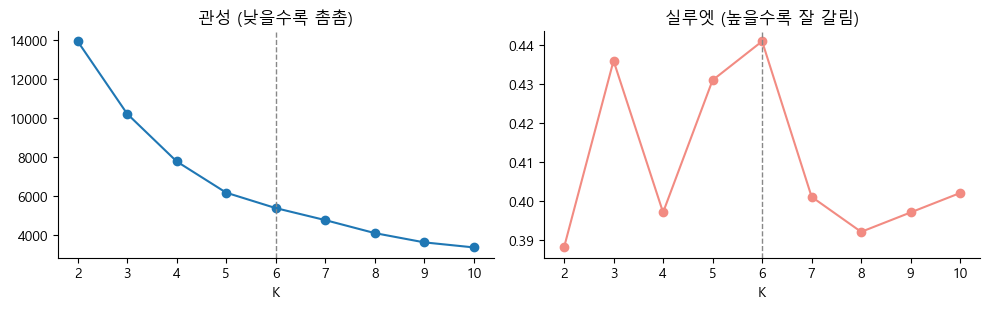

점선이 아래에서 쓸 K=6. 실루엣이 여기서 가장 높다.


In [6]:
import logging

import matplotlib.pyplot as plt

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
plt.rcParams["font.family"] = ["Malgun Gothic", "AppleGothic", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

probe_df = pd.DataFrame(rows)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 3.2))
a1.plot(probe_df["K"], probe_df["관성"], "o-"); a1.set_title("관성 (낮을수록 촘촘)")
a2.plot(probe_df["K"], probe_df["실루엣"], "o-", color="#f28b82"); a2.set_title("실루엣 (높을수록 잘 갈림)")
for a in (a1, a2):
    a.axvline(6, ls="--", color="#888", lw=1); a.set_xlabel("K")
    for s in ("top", "right"):
        a.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

print("점선이 아래에서 쓸 K=6. 실루엣이 여기서 가장 높다.")

## 6. 세그먼트 방식 만들기

축을 갈아끼울 수 있게 작은 클래스로 감쌌다.

- `fit`: 훈련용 고객을 K덩어리로 나누고, **덩어리마다 그 사람들이 실제로 쓰는 요금제
  상위 5개**를 기억한다
- `recommend_for`: 새 사용자가 어느 덩어리인지 보고, 그 덩어리의 요금제 5개를 그대로 내민다

주목할 점: `recommend_for`는 사용자의 예산도 데이터 요구량도 **보지 않는다**.
덩어리 번호만 보고 답한다. 이게 세그먼트 방식의 정의다.

In [7]:
K = 6


class SegmentModel:
    """KMeans 군집 -> 그 세그먼트가 쓰는 요금제."""

    def __init__(self, axes, name):
        self.axes, self.name = axes, name

    def fit(self, df):
        x = make_axes(df)[self.axes]
        self.pipe = make_pipeline(StandardScaler(), KMeans(K, random_state=SEED, n_init=10))
        labels = self.pipe.fit_predict(x)
        # 세그먼트마다 그 사람들이 실제로 쓰는 요금제 상위 TOP_N개
        self.plans_by_segment = {
            seg: df.loc[labels == seg, "source_plan_id"].value_counts().head(TOP_N).index.tolist()
            for seg in range(K)
        }
        self.labels_ = labels
        return self

    def segment_of(self, df):
        return self.pipe.predict(make_axes(df)[self.axes])

    def recommend_for(self, seg):
        """이 세그먼트에 주는 요금제. 사용자의 조건은 보지 않는다."""
        return plans[plans["plan_id"].isin(self.plans_by_segment[seg])]


seg_req = SegmentModel(REQUIRED_AXES, "세그먼트(필수 2축)").fit(train)
seg_all = SegmentModel(ALL_AXES, "세그먼트(전체 7축)").fit(train)
print("세그먼트 생성 완료")

세그먼트 생성 완료


## 7. 어떤 덩어리가 만들어졌나

전체 축으로 만든 세그먼트 6개가 각각 어떤 사람들인지 본다.

In [8]:
prof = train.assign(세그먼트=seg_all.labels_).groupby("세그먼트").agg(
    인원=("customer_id", "size"),
    평균예산=("budget_krw", "mean"),
    평균GB=("data_gb_month", "mean"),
    평균나이=("age", "mean"),
    통화무제한=("voice_unlimited_need", "mean"),
).round(1)
prof["통화무제한"] = (prof["통화무제한"] * 100).round(0).astype(int).astype(str) + "%"
prof["이 세그먼트가 받는 요금제"] = [
    ", ".join(plans.set_index("plan_id").reindex(seg_all.plans_by_segment[s])["plan_name"]
              .fillna("?").head(3)) + " …"
    for s in prof.index
]
display(prof)

,인원,평균예산,평균GB,평균나이,통화무제한,이 세그먼트가 받는 요금제
세그먼트,,,,,,
0,8092,6927.0,9.0,47.9,100%,"[모요only] 마블링 프라임 11GB+매일2GB+3Mbps, [모요only] 마블..."
1,6141,13730.2,88.3,46.0,100%,"[모요only] [K] 핀다이렉트Z Max (100GB) _PIN, [모요only]..."
2,1112,9154.0,47.2,47.8,90%,"EG 무제한 7GB+1M(밀리의 서재), [모요only] 쉐이크only LTE 10..."
3,8335,3455.3,10.1,49.8,0%,"티플 가성비(300분/6GB)_평생요금, 티플 가성비(300분/6GB)_평생요금, ..."
4,2205,9711.9,50.8,47.3,100%,"EG 무제한 7GB+1M(밀리의 서재), [모요only] 쉐이크only LTE 10..."
5,2115,33044.7,74.5,46.4,100%,"[모요only] [K] 핀다이렉트Z Max (100GB)(12) _PIN, [평생할..."


## 8. 시험 — 세 방식을 같은 사람들에게 돌린다

시험용 고객 1,500명을 뽑아 세 방식에 똑같이 넣는다.

1. **세그먼트(필수 2축)** — 예산·데이터로만 나눈 덩어리의 요금제
2. **세그먼트(전체 7축)** — 전부 써서 나눈 덩어리의 요금제
3. **필터 + 랭킹** — 군집 없이 `recommend()`

각 사람마다 `broken_rules()`로 어긴 조건을 세고, 마지막에 비율로 낸다.

> **먼저 걸러지는 사람이 있다.** 알뜰폰에는 프로모션으로 월 0원인 요금제가 14개 있고,
> 합성 고객의 4.66%(1,864명)가 거기서 나와 예산이 0원이다. 폼이 `예산을 1원 이상`으로
> 막으므로 이들은 시험에서 빠진다. 세 방식 모두에서 똑같이 빠지므로 비교는 공정하다.

In [9]:
N_TEST = 1_500
sample = test.sample(N_TEST, random_state=SEED)

queries, rows_ok, rejected = [], [], []
for _, row in sample.iterrows():
    try:
        queries.append(persona_to_query(row))
        rows_ok.append(row)
    except InputError as e:
        rejected.append(str(e))
sample_ok = pd.DataFrame(rows_ok)

print(f"시험 대상 {len(queries):,}명 (폼이 거부한 {len(rejected)}명 제외)")
if rejected:
    display(pd.Series(rejected).value_counts().rename("거부된 인원").to_frame())

seg_req_ids = seg_req.segment_of(sample_ok)
seg_all_ids = seg_all.segment_of(sample_ok)


def evaluate(name, get_result):
    """방식 하나를 1,500명에게 돌리고 위반을 센다."""
    out = []
    for i, q in enumerate(queries):
        got = get_result(i, q)
        out.append({
            "위반": broken_rules(got, q),
            "n": len(got),
            "요금": int(got["discounted_fee"].median()) if len(got) else None,
            "조합": tuple(sorted(got["plan_id"])) if len(got) else (),
        })
    df = pd.DataFrame(out)
    viol = df["위반"].explode().dropna()
    return {
        "방식": name,
        "예산 초과": (viol == "예산").groupby(viol.index).any().reindex(df.index, fill_value=False).mean(),
        "데이터 부족": viol.isin(["데이터", "무제한"]).groupby(viol.index).any().reindex(df.index, fill_value=False).mean(),
        "통화·문자 위반": viol.isin(["통화무제한", "문자무제한", "통화분수", "문자건수"]).groupby(viol.index).any().reindex(df.index, fill_value=False).mean(),
        "하나라도 위반": df["위반"].str.len().gt(0).mean(),
        "추천 0건": df["n"].eq(0).mean(),
        "요금 중앙값": int(df["요금"].median()) if df["요금"].notna().any() else 0,
        "서로 다른 답": df["조합"].nunique(),
    }


results = [
    evaluate("세그먼트(필수 2축)", lambda i, q: seg_req.recommend_for(seg_req_ids[i])),
    evaluate("세그먼트(전체 7축)", lambda i, q: seg_all.recommend_for(seg_all_ids[i])),
    evaluate("필터 + 랭킹", lambda i, q: recommend(plans, **q)),
]
print("완료")

시험 대상 1,435명 (폼이 거부한 65명 제외)


,거부된 인원
예산을 1원 이상으로 입력해 주세요.,65


완료


In [10]:
res = pd.DataFrame(results).set_index("방식")
show = res.copy()
for c in ("예산 초과", "데이터 부족", "통화·문자 위반", "하나라도 위반", "추천 0건"):
    show[c] = show[c].map("{:.1%}".format)
show["요금 중앙값"] = show["요금 중앙값"].map("{:,}원".format)
show["서로 다른 답"] = show["서로 다른 답"].astype(str) + f" / {len(queries):,}명"
display(show.T)

방식,세그먼트(필수 2축),세그먼트(전체 7축),필터 + 랭킹
예산 초과,81.7%,65.4%,0.0%
데이터 부족,72.3%,90.7%,0.0%
통화·문자 위반,20.1%,18.0%,0.0%
하나라도 위반,93.1%,98.3%,0.0%
추천 0건,0.0%,0.0%,1.7%
요금 중앙값,"7,950원","6,900원","2,200원"
서로 다른 답,"6 / 1,435명","6 / 1,435명","54 / 1,435명"


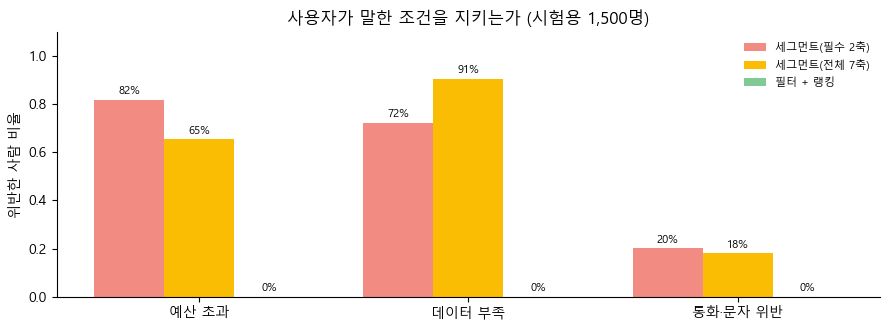

In [11]:
fig, ax = plt.subplots(figsize=(9, 3.4))
metrics = ["예산 초과", "데이터 부족", "통화·문자 위반"]
x = np.arange(len(metrics))
w = 0.26
colors = ["#f28b82", "#fbbc04", "#81c995"]
for j, (name, r) in enumerate(res.iterrows()):
    b = ax.bar(x + (j - 1) * w, [r[m] for m in metrics], w, label=name, color=colors[j])
    ax.bar_label(b, labels=[f"{r[m]:.0%}" for m in metrics], padding=2, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(metrics)
ax.set_ylabel("위반한 사람 비율"); ax.set_ylim(0, 1.1)
ax.set_title("사용자가 말한 조건을 지키는가 (시험용 1,500명)")
ax.legend(fontsize=8, frameon=False)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

## 9. 왜 이렇게 되는가 — 세그먼트는 답을 뭉갠다

위 표의 **"서로 다른 답"** 줄이 핵심이다.

세그먼트 방식은 덩어리가 K개뿐이라 답도 최대 K가지다. 1,500명이 서로 다른 예산과
데이터 요구를 말해도 돌아오는 답은 6종류다. 예산 9,000원인 사람과 24,000원인 사람이
같은 덩어리에 묶이면 **둘에게 같은 요금제가 나간다.** 한쪽은 반드시 예산을 넘긴다.

필터 + 랭킹은 조건을 하나씩 확인하고 거르므로 사람마다 답이 달라진다.

아래에서 실제로 얼마나 뭉개지는지 본다.

In [12]:
seg_view = pd.DataFrame({
    "세그먼트": seg_all_ids,
    "예산": sample_ok["budget_krw"].to_numpy(),
})
spread = seg_view.groupby("세그먼트")["예산"].agg(["size", "min", "max", "median"])
spread["세그먼트가 주는 최고가"] = [
    int(plans[plans["plan_id"].isin(seg_all.plans_by_segment[s])]["discounted_fee"].max())
    for s in spread.index
]
spread["예산 넘는 사람"] = [
    f"{(seg_view.loc[seg_view['세그먼트'] == s, '예산'] < spread.loc[s, '세그먼트가 주는 최고가']).mean():.0%}"
    for s in spread.index
]
display(spread.rename(columns={"size": "인원", "min": "예산 최소", "max": "예산 최대", "median": "예산 중앙"}))

print("한 덩어리 안에서 예산이 몇 배까지 벌어지는지 보라.")
print("그 덩어리에 하나의 요금제 묶음을 주면, 예산이 낮은 쪽은 반드시 초과한다.")

,인원,예산 최소,예산 최대,예산 중앙,세그먼트가 주는 최고가,예산 넘는 사람
세그먼트,,,,,,
0,366,10,26400,7800.0,8750,62%
1,330,8400,24000,12000.0,15800,73%
2,55,10,33100,8400.0,14900,76%
3,470,10,28600,900.0,1900,54%
4,120,10,33100,11000.0,14900,70%
5,94,24000,53000,32695.0,53000,98%


한 덩어리 안에서 예산이 몇 배까지 벌어지는지 보라.
그 덩어리에 하나의 요금제 묶음을 주면, 예산이 낮은 쪽은 반드시 초과한다.


## 10. 결론 — 세그먼트 ML은 필요한가

**필요하지 않다.** 근거 셋.

**하나. 입력을 늘려도 나아지지 않는다.**
군집 축을 2개에서 7개로 늘려도 위반율이 의미 있게 떨어지지 않는다. 사용자에게 5개를
더 묻는 값어치가 나오지 않는다. 원래 이 노트북이 답하려던 질문의 답이 이것이다.

**둘. 축을 아무리 잘 골라도 구조가 막는다.**
세그먼트 방식은 사용자의 예산을 **보지 않는다**. 덩어리 번호만 보고 답한다.
9절 표를 보면 한 덩어리 안에서 예산이 몇 배씩 벌어지는데, 그 덩어리에 요금제 묶음
하나를 주면 낮은 쪽은 반드시 초과한다. K를 키우면 줄어들지만, K를 무한히 키우면
그건 그냥 사람마다 따로 거르는 것 — 필터다.

**셋. 대조군이 전부 0%다.**
필터 + 랭킹은 조건을 직접 확인하므로 위반이 0이다. 학습도, 모델 파일도, 재학습
파이프라인도 없이 그렇다. **모델을 둬서 나빠졌다.**

### 나이를 넣었는데도 왜 안 나아지나

이 합성 데이터는 나이를 요금대에 조건부로 뽑아 **일부러 상관을 심어 둔 것**이다
(나이–GB 상관 −0.101). 그런데도 나이를 축에 넣은 쪽이 나아지지 않는다.

이유는 신호가 약해서가 아니라 **문제가 다르기 때문**이다. 나이는 "이 사람이 대충
어느 가격대일까"를 조금 알려줄 뿐, "이 사람 예산이 9,300원이다"를 알려주지 못한다.
추천이 지켜야 하는 건 후자다. 통계적 경향으로는 개별 제약을 대신할 수 없다.

### 이 실험이 답하지 못하는 것

- 합성 데이터는 요금제 스펙에서 사람을 역산한 것이라 순환이 있다. 답한 건 "현실에
  숨은 세그먼트가 있는가"가 아니라 **"우리 입력으로 추천하는 데 군집이 필요한가"** 다
- 시험용이 훈련용과 같은 분포다. 세그먼트 방식에 **유리하게 기운** 시험인데도 졌다
- 알뜰폰 데이터라 '알뜰폰'·'가입불가' 위반 축은 구조적으로 0이다. 이 둘은 빼고 읽어야 한다

### 그래서 세그먼트를 어디에 쓰나

추천 자체에는 안 쓴다. 다만 군집은 **설명**에는 쓸모가 있다 — "이런 사람들이 이런
요금제를 많이 씁니다" 같은 화면이나, 어느 사용자 층이 비는지 보는 데는 여전히 쓴다.
추천 경로에 넣지 말라는 것이지 버리라는 뜻이 아니다.